In [5]:
import os
import h5py

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tqdm import tqdm
import cv2
import matplotlib.pyplot as plt  

In [6]:
base_dir = r"C:\Users\karti\edi\Dataset2"  
train_csv_path = os.path.join(base_dir, "train_1.csv")
train_images_path = os.path.join(base_dir, "train_images")
val_csv_path = os.path.join(base_dir, "valid.csv")
val_images_path = os.path.join(base_dir, "val_images")

df_train = pd.read_csv(train_csv_path)
df_val = pd.read_csv(val_csv_path)

In [7]:
def preprocess_images(df, image_dir, img_size=(224, 224)):
    images = []
    labels = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Processing images"):
        img_path = os.path.join(image_dir, row['id_code'] + ".png")
        if os.path.exists(img_path):
          
            img = cv2.imread(img_path)
            img = cv2.resize(img, img_size)  
            img = img / 255.0  

            images.append(img)
            labels.append(row['diagnosis'])
        else:
            print(f"Image not found: {img_path}")

    images = np.array(images)
    labels = np.array(labels)
    return images, labels


images_train, labels_train = preprocess_images(df_train, train_images_path)
images_val, labels_val = preprocess_images(df_val, val_images_path)

labels_train = to_categorical(labels_train, num_classes=5)
labels_val= to_categorical(labels_val, num_classes=5)\

print(f"Training data shape: {df_train.shape}")

Processing images: 100%|██████████| 366/366 [00:17<00:00, 21.19it/s]


Training data shape: (2930, 2)


In [15]:

import tensorflow as tf; 
print(tf.config.list_physical_devices('GPU'))

[]


In [8]:
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(5, activation='softmax')  
])


cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


history = cnn_model.fit(images_train, labels_train, epochs=10, validation_data=(images_val, labels_val), batch_size=32)
import h5py
model_path = os.path.join(base_dir, "cnn_model.h5")
cnn_model.save(model_path)
print(f"Model saved to {model_path}")

Epoch 1/10
92/92 [==============================] - 31s 329ms/step - loss: 1.1495 - accuracy: 0.6833 - val_loss: 0.7575 - val_accuracy: 0.7158
Epoch 2/10
92/92 [==============================] - 28s 309ms/step - loss: 0.7587 - accuracy: 0.7249 - val_loss: 0.7378 - val_accuracy: 0.7186
Epoch 3/10
92/92 [==============================] - 30s 322ms/step - loss: 0.7317 - accuracy: 0.7276 - val_loss: 0.7176 - val_accuracy: 0.7432
Epoch 4/10
92/92 [==============================] - 29s 316ms/step - loss: 0.7114 - accuracy: 0.7365 - val_loss: 0.7129 - val_accuracy: 0.7541
Epoch 5/10
92/92 [==============================] - 29s 316ms/step - loss: 0.6901 - accuracy: 0.7410 - val_loss: 0.6916 - val_accuracy: 0.7623
Epoch 6/10
92/92 [==============================] - 29s 314ms/step - loss: 0.6602 - accuracy: 0.7577 - val_loss: 0.7266 - val_accuracy: 0.7268
Epoch 7/10
92/92 [==============================] - 29s 312ms/step - loss: 0.6382 - accuracy: 0.7686 - val_loss: 0.7795 - val_accuracy: 0.7404

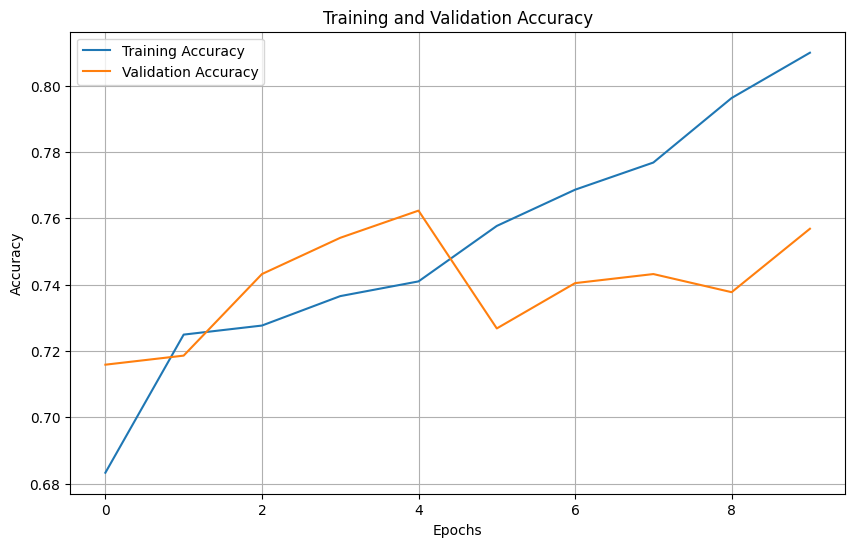

In [9]:
def plot_accuracy_graph(history):
    
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='best')
    plt.grid(True)

   
    plt.show()


plot_accuracy_graph(history)

In [4]:
import cv2
import numpy as np
import tensorflow as tf


image_path = r'C:\Users\karti\edi\Dataset2\test_images\e4dcca36ceb4.png'  


img = cv2.imread(image_path)


if img is None:
    print("Error: Unable to load image. Please check the image path.")
else:
    print("Image loaded successfully!")

    img = cv2.resize(img, (224, 224))  
    img = img / 255.0  
    img = np.expand_dims(img, axis=0)  

    cnn_model = tf.keras.models.load_model(r'C:\Users\karti\edi\Dataset2\cnn_model.h5')

  
    prediction = cnn_model.predict(img)
    predicted_class = np.argmax(prediction)
    
    
    class_names = ['No_DR', 'Mild', 'Moderate', 'Severe', 'Proliferate_DR']
    print(f"Predicted Class: {class_names[predicted_class]}")


Image loaded successfully!


c:\Users\karti\edi\edi\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\karti\edi\edi\Lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
Predicted Class: No_DR


In [ ]:
import tkinter as tk
from tkinter import filedialog, messagebox
from PIL import Image, ImageTk
import numpy as np
import cv2
import tensorflow as tf
import threading  


model_path = r'C:\Users\karti\edi\Dataset2\cnn_model.h5'  
cnn_model = tf.keras.models.load_model(model_path)


class_names = ['No_DR', 'Mild', 'Moderate', 'Severe', 'Proliferate_DR']

def preprocess_image(image_path):
   
    img = cv2.imread(image_path)
    if img is None:
        messagebox.showerror("Error", "Error loading image!")
        return None
    img = cv2.resize(img, (224, 224))  
    img = img / 255.0  
    img = np.expand_dims(img, axis=0)  
    return img

def predict_image():
    
    file_path = filedialog.askopenfilename(title="Select an Image", filetypes=[("Image files", "*.png;*.jpg;*.jpeg")])
    
    if file_path:
       
        threading.Thread(target=run_prediction, args=(file_path,)).start()

def run_prediction(image_path):
   
    img = preprocess_image(image_path)
    
    if img is not None:
       
        prediction = cnn_model.predict(img)
        predicted_class = class_names[np.argmax(prediction)]  
        predicted_label=tk.Label(window,text= "Predicted Class is "+ predicted_class)
        predicted_label.grid(row=2,column=3,padx=10,pady=10)
        
       
        #messagebox.showinfo("Prediction Result", f"The image is classified as: {predicted_class}")
        
    
        display_image(image_path)

def display_image(image_path):
    
    img = Image.open(image_path)
    img = img.resize((300, 300))  
    img = ImageTk.PhotoImage(img)
    
   
    panel = tk.Label(window, image=img)
    panel.image = img  
    panel.grid(row=1, column=3, columnspan=2)


window = tk.Tk()
window.geometry("400x640+0+0")
window.title("Diabetes Detection Using Machine Learning")

title_label=tk.Label(window,text="Diabetes Detection",font=("Algerian Regular",30,"bold"),border=12,relief=tk.RAISED,bg="red",foreground="white") 
title_label.grid(row=0,column=3,padx=10,pady=10)


predict_button = tk.Button(window, text="Load and Predict Image", command=predict_image)
predict_button.grid(row=3, column=3, padx=10, pady=10)


window.mainloop()
